In [62]:
from langchain_groq import ChatGroq
from langchain_core.messages import AIMessage,SystemMessage,HumanMessage,BaseMessage
from typing import TypedDict,Annotated,Literal
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

from langgraph.prebuilt import ToolNode,tools_condition
from langchain_core.tools import tool
from dotenv import load_dotenv
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [63]:
load_dotenv()

True

In [64]:
llm=ChatGroq(
    model='openai/gpt-oss-20b'
)

In [65]:
loader=PyPDFLoader('test.pdf')

docs=loader.load()

In [66]:
len(docs)

10

In [67]:
splitter=RecursiveCharacterTextSplitter(chunk_size=800,chunk_overlap=150)
splitter

In [68]:
chunks=splitter.split_documents(docs)

In [69]:
len(chunks)

81

In [70]:
load_dotenv()
from langchain_google_genai import GoogleGenerativeAIEmbeddings

embeddings=GoogleGenerativeAIEmbeddings(
    model='gemini-embedding-2'
)


In [71]:
vector_store=FAISS.from_documents(
    documents=chunks,
    embedding=embeddings
)

In [72]:
retriever=vector_store.as_retriever(search_type='similarity',search_kwargs={'k':4})

In [73]:
result=retriever.invoke('explain Methodology')

In [74]:
[doc.page_content for doc in result]


['where n stands for the number of possible classes [39, 14, 41, 16]. These two layers are fully connected and previously\nmentioned routing by agreement ensures that each capsule receives the entire input of the primary output [39, 14, 41].\nThese n capsules now use their vectors to calculate the probability for their respective classes [39, 14].\n3. Methodology\nIn this work, a hybrid three-stage detection and classification model pipeline is proposed in which individual\nmodels (YOLOv11 and CapsNet) utilize their detection and classification strengths to support another YOLOv11',
 '∗ Corresponding author.\nE-mail address: christoph.mattmann@hs-aalen.de\n1877-0509 © 2025 The Authors. Published by Elsevier B.V .\nThis is an open access article under the CC BY -NC-ND license (http://creativecommons.org/licenses/by-nc-nd/4.0/)\nPeer-review under responsibility of the scientific committee of the KES International.\n© 2025 The Authors. Published by Elsevier B.V .\nThis is an open access a

In [75]:
load_dotenv()

True

In [76]:
@tool
def rag_tool(query):

    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """
    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        'query': query,
        'context': context,
        'metadata': metadata
    }

In [77]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [78]:
class chatState(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]


In [79]:
def chat_node(state:chatState):
    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """

    response=llm_with_tools.invoke(state['messages'])

    return{'messages':[response]}

In [80]:
tool_node=ToolNode(tools)

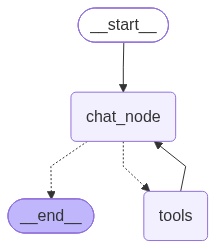

In [81]:
graph=StateGraph(chatState)

graph.add_node('chat_node',chat_node)
graph.add_node('tools',tool_node)

graph.add_edge(START,'chat_node')
graph.add_conditional_edges('chat_node',tools_condition)
graph.add_edge('tools','chat_node')

ragbot=graph.compile()
ragbot

In [82]:
response=ragbot.invoke(
    {
        'messages':[HumanMessage(
            content="Hello,What is your name babe?"
        )]
    }
)

In [83]:
response

{'messages': [HumanMessage(content='Hello,What is your name babe?', additional_kwargs={}, response_metadata={}, id='9a578f8a-c380-405d-8ce5-9fc07932814b'),
  AIMessage(content='Hello! I’m ChatGPT, your AI assistant. How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "Hello,What is your name babe?" They are addressing me. I should respond politely. It\'s a casual greeting. I should say something like "Hello! I\'m ChatGPT, your AI assistant." No need to use the rag_tool.'}, response_metadata={'token_usage': {'completion_tokens': 79, 'prompt_tokens': 151, 'total_tokens': 230, 'completion_time': 0.081936456, 'completion_tokens_details': {'reasoning_tokens': 52}, 'prompt_time': 0.007431521, 'prompt_tokens_details': None, 'queue_time': 0.355454554, 'total_time': 0.089367977}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_1074f9ce08', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--0

In [84]:
response['messages'][-1].content

'Hello! I’m ChatGPT, your AI assistant. How can I help you today?'

In [85]:
response=ragbot.invoke(
    {
        'messages':[HumanMessage(
            content="use tool and Give me the summary of this PDF?"
        )]
    }
)

response

{'messages': [HumanMessage(content='use tool and Give me the summary of this PDF?', additional_kwargs={}, response_metadata={}, id='7cdbc29d-74e8-4d20-988d-aa8ea1cb5123'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to use rag_tool to get summary. The PDF is presumably uploaded? We need to ask rag_tool with a query. The query could be "summary of this PDF". We\'ll call the function.', 'tool_calls': [{'id': 'fc_3457455c-ea79-4b6a-b720-60388266e007', 'function': {'arguments': '{"query":"summary of this PDF"}', 'name': 'rag_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 69, 'prompt_tokens': 154, 'total_tokens': 223, 'completion_time': 0.07883386, 'completion_tokens_details': {'reasoning_tokens': 42}, 'prompt_time': 0.008930761, 'prompt_tokens_details': None, 'queue_time': 0.354692503, 'total_time': 0.087764621}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_1074f9ce08', 'service_tier': 'on_demand', 'finis

In [87]:
print(response['messages'][-1].content)

**Summary of the PDF**

The article presents a deep‑learning framework that integrates **YOLOv11** (for object detection) with a **Capsule Network (CapsNet)** (for fine‑grained classification) to improve the detection and characterization of pulmonary nodules in thoracic CT and PET/CT scans.

| Component | Purpose | Key Findings |
|-----------|---------|--------------|
| **Datasets** | • LIDC‑IDRI (1,010 CT cases with radiologist annotations)  <br>• Lung‑PET‑CT‑Dx (large‑scale CT/PET dataset for lung cancer) | Combined to provide a diverse training set of >53,000 images. |
| **Model Variants** | • Full‑Image CapsNet (entire scan as input)  <br>• Cropped‑Image CapsNet (only the ROI around a nodule)  <br>• YOLOv11 alone  <br>• YOLOv11 + Cropped‑Image CapsNet | Cropped‑Image CapsNet outperforms the full‑image version: <br>• Accuracy: 95.57 % vs 93.07 %  <br>• Precision: 96.42 % vs 92.36 %  <br>• Recall: 94.67 % vs 94.00 %  <br>• F1‑Score: 95.53 % vs 93.17 % |
| **Overall System** | The YO

In [88]:
response=ragbot.invoke(
    {
        'messages':[HumanMessage(
            content="What is the Methodology of this PDF?"
        )]
    }
)

response

{'messages': [HumanMessage(content='What is the Methodology of this PDF?', additional_kwargs={}, response_metadata={}, id='e49c0da4-43df-4a89-8fae-14d79bac6ca3'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is the Methodology of this PDF?" They want to know the methodology section of a PDF. We need to retrieve the PDF. We have a tool `functions.rag_tool` to retrieve information. We need to call the function with query "Methodology of this PDF". But we need to specify the query. We don\'t know the PDF name. The user didn\'t provide the PDF. Possibly they have a PDF loaded in the system. The instructions: "Use this tool when the user asks factual / conceptual questions that might be answered from the stored documents." So we should use rag_tool to search for "Methodology" in the PDF. We need to pass query: "Methodology". Let\'s do that.', 'tool_calls': [{'id': 'fc_92c3b604-90e3-446d-aaac-cc80fc5c6f59', 'function': {'arguments': '{"query":"Methodo

In [89]:
print(response['messages'][-1].content)

**Methodology (as described in the PDF)**  

The paper proposes a **three‑stage hybrid pipeline** that fuses the detection power of YOLOv11 with the classification strength of a Capsule Network (CapsNet) to identify and classify lung nodules in CT and PET/CT images.

| Stage | Purpose | Key components & steps |
|-------|---------|------------------------|
| **1. Initial detection (YOLOv11)** | Roughly locate candidate nodule regions. | • YOLOv11 is trained on the full CT/PET‑CT dataset. <br>• Produces bounding boxes and confidence scores for every potential nodule. |
| **2. Classification (CapsNet)** | Refine the initial detections by classifying the content inside each bounding box. | • The cropped ROI from stage 1 is fed to a CapsNet that preserves spatial hierarchies. <br>• CapsNet outputs class probabilities (e.g., benign vs malignant). |
| **3. Final refinement (YOLOv11)** | Re‑evaluate the ROI with a second YOLOv11 that benefits from the CapsNet’s class information. | • The class